# Training Results Visualization

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from adjustText import adjust_text

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

# Experiment Configuration

Specify the training-test combination you want to analyze
- Available training datasets: alpaca, dolly, flan_v2, cot, oasst1, vicuna, wizardlm, openhermes, tulu3, less
- Available tasks: tydiqa, samsum, gsm8k, math500, mmlu (with subject)

## Method Definitions

Each method is defined by 4 components:
1. **Selection**: `NA` (none), `Streaming` (per-layer), or `GREATS` (global)
2. **Compression**: `NA`, `GraSS` (gradient sparse sketch), or `LoGra` (low-rank gradient)
3. **Training Type**: `full` (full fine-tuning) or `lora` (LoRA fine-tuning)
4. **Second-Order**: `False` or `True` - enables greedy selection with second-order interactions

### Key Design Principle

**Compression controls both scoring AND optimizer:**
- If compression is specified (`GraSS` or `LoGra`) → Use compressed gradients for scoring AND MeSO optimizer
- If no compression (`NA`) → Use full gradients for scoring AND standard AdamW optimizer

## Naming Convention

Directory format: `{train}_{task}-{selection}-{compression}-{model}-{training_type}-p{pct}-lr{lr}-b{batch}-v{nval}-s{seed}`

- **Streaming**: Per-layer selection (on-the-fly gradient streaming) - each layer independently selects samples
- **GREATS**: Global selection - accumulates scores across all layers, then selects globally

## Available Configurations (14 total)

| # | Configuration | Description |
|---|---------------|-------------|
| 1a | NA-NA-full | Baseline full fine-tuning |
| 1b | NA-NA-lora | Baseline LoRA fine-tuning |
| 2a | Streaming-NA-full | Per-layer selection, full gradients |
| 2b | Streaming-NA-lora | Per-layer selection, full gradients, LoRA |
| 3a | GREATS-NA-full | Global selection, full gradients |
| 3b | GREATS-NA-lora | Global selection, full gradients, LoRA |
| 4a | NA-GraSS-full | MeSO only with GraSS (no selection) |
| 4b | NA-LoGra-full | MeSO only with LoGra (no selection) |
| 5a | Streaming-GraSS-full | Per-layer selection + MeSO (GraSS) |
| 5b | Streaming-LoGra-full | Per-layer selection + MeSO (LoGra) |
| 6a | GREATS-GraSS-full | Global selection + MeSO (GraSS) |
| 6b | GREATS-LoGra-full | Global selection + MeSO (LoGra) |
| 7a | Streaming-GraSS-2nd-full | Per-layer + MeSO + second-order |
| 7b | GREATS-GraSS-2nd-full | Global + MeSO + second-order |

In [2]:
model = 'llama3-1b'
train_dataset = 'tulu3'  # Options: alpaca, less, wizardlm, tulu3
task = 'samsum'          # Options: tydiqa, samsum
subject = None           # Only needed for mmlu/bbh tasks (e.g., 'sociology', 'abstract_algebra')
out_dir = "/scratch/pbb/Project/Gradient-Streaming/SFT"

# Configuration used for experiments
# See SFT/README.md for recommended parameters per dataset
default_config = {
    'batch_size': 8,
    'percentage': 0.02,   # tulu3: 0.02, alpaca: 0.9, less: 0.1, wizardlm: 0.2
    'n_val': 8,
    'lr_full': '5e-06',   # Learning rate for full fine-tuning
    'lr_lora': '1e-04',   # Learning rate for LoRA fine-tuning
    'seed': 42,
}

# ============================================
# Plot Filtering Options
# ============================================
show_second_order = True       # Set to True to include +2nd methods
show_per_layer = True          # Set to True to include Per-layer (Streaming) selection methods
show_lora = True               # Set to True to include LoRA methods

In [ ]:
# Each method is defined by: (selection, compression, training_type, use_second_order)
# - selection: 'NA', 'Streaming' (per-layer), or 'GREATS' (global)
# - compression: 'NA', 'GraSS', or 'LoGra' (compression implies MeSO optimizer)
# - training_type: 'full' or 'lora'
# - use_second_order: False (default) or True - greedy selection with second-order interactions
#
# Key design principle:
# - Compression controls both scoring AND optimizer
# - With compression (GraSS/LoGra): compressed gradients + MeSO optimizer
# - Without compression (NA): full gradients + standard AdamW optimizer

method_definitions = {
    # ============================================
    # 1. Baselines (NA-NA): no selection, no compression
    # ============================================
    'NA-NA-full': ('NA', 'NA', 'full', False),
    'NA-NA-lora': ('NA', 'NA', 'lora', False),

    # ============================================
    # 2. Streaming without compression (Streaming-NA)
    #    Per-layer selection, full gradients, standard optimizer
    # ============================================
    'Streaming-NA-full': ('Streaming', 'NA', 'full', False),
    'Streaming-NA-lora': ('Streaming', 'NA', 'lora', False),

    # ============================================
    # 3. GREATS without compression (GREATS-NA)
    #    Global selection, full gradients, standard optimizer
    # ============================================
    'GREATS-NA-full': ('GREATS', 'NA', 'full', False),
    'GREATS-NA-lora': ('GREATS', 'NA', 'lora', False),

    # ============================================
    # 4. MeSO only (NA-{compression})
    #    No selection, compressed gradients, MeSO optimizer
    # ============================================
    'NA-GraSS-full': ('NA', 'GraSS', 'full', False),
    'NA-LoGra-full': ('NA', 'LoGra', 'full', False),

    # ============================================
    # 5. Streaming with compression (Streaming-{compression})
    #    Per-layer selection, MeSO optimizer
    # ============================================
    'Streaming-GraSS-full': ('Streaming', 'GraSS', 'full', False),
    'Streaming-LoGra-full': ('Streaming', 'LoGra', 'full', False),

    # ============================================
    # 6. GREATS with compression (GREATS-{compression})
    #    Global selection, MeSO optimizer
    # ============================================
    'GREATS-GraSS-full': ('GREATS', 'GraSS', 'full', False),
    'GREATS-LoGra-full': ('GREATS', 'LoGra', 'full', False),

    # ============================================
    # 7. Second-order variants (with compression)
    # ============================================
    'Streaming-GraSS-2nd-full': ('Streaming', 'GraSS', 'full', True),
    'GREATS-GraSS-2nd-full': ('GREATS', 'GraSS', 'full', True),
}

# Filter methods based on options
def should_include_method(name, definition):
    """Check if a method should be included based on filter settings."""
    selection, compression, training_type, use_second_order = definition

    # Filter second-order methods
    if not show_second_order and use_second_order:
        return False

    # Filter per-layer selection methods (Streaming)
    if not show_per_layer and selection == 'Streaming':
        return False

    # Filter LoRA methods
    if not show_lora and training_type == 'lora':
        return False

    return True

# Apply filters
filtered_methods = {name: defn for name, defn in method_definitions.items()
                    if should_include_method(name, defn)}

print(f"Showing {len(filtered_methods)}/{len(method_definitions)} methods:")
for name in filtered_methods:
    print(f"  - {name}")

## Load Results

In [4]:
def load_results(result_path):
    """Load evaluation results from JSON file."""
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]
    wall_time = [item.get('wall_time', None) for item in data]

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
        'wall_time': np.array(wall_time) if all(t is not None for t in wall_time) else None,
    }


def build_experiment_path(train_dataset, task, method_name, config=None, subject=None):
    """
    Build the experiment directory path based on the naming convention.

    Directory format:
    {train_dataset}_{task}-{method_str}-{model}-{job_type}-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}

    Method string naming convention:
    - {selection}-{compression}[-2nd]
    - Streaming = per-layer selection (on-the-fly gradient streaming)
    - GREATS = global selection (accumulate scores across all layers)

    Examples:
    - NA-NA: baseline (no selection, no compression)
    - Streaming-GraSS: per-layer data selection with GraSS compression (MeSO)
    - NA-GraSS: MeSO optimizer only (no selection)
    - GREATS-GraSS: global selection with GraSS compression (MeSO)
    - Streaming-GraSS-2nd: per-layer selection with MeSO + second-order
    """
    if method_name not in method_definitions:
        return None

    # Get method definition (4 elements)
    selection, compression, training_type, use_second_order = method_definitions[method_name]

    # Use default config or provided config
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']
    seed = cfg['seed']
    lr = cfg['lr_lora'] if training_type == 'lora' else cfg['lr_full']

    # Build method string: selection-compression[-2nd]
    method_str = f"{selection}-{compression}"

    # Add '-2nd' suffix for data selection with second-order interactions
    if selection != 'NA' and use_second_order:
        method_str = f"{method_str}-2nd"

    # Build setting string: model-job_type-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}
    setting_str = f"{model}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}"

    # Build task string (with subject for MMLU/BBH)
    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    # Full directory name
    dir_name = f"{train_dataset}_{task_str}-{method_str}-{setting_str}"

    return f"{out_dir}/{dir_name}/evaluation_results.json"


# Build experiment paths for FILTERED methods only
experiments = {}
for method_name in filtered_methods.keys():
    path = build_experiment_path(train_dataset, task, method_name, default_config, subject)
    if path:
        experiments[method_name] = path

# Load all results
results = {}
print(f"Loading results for: {train_dataset} -> {task}")
print("=" * 60)

for name, path in experiments.items():
    if Path(path).exists():
        results[name] = load_results(path)
        print(f"+ {name}: {len(results[name]['steps'])} evaluation points")
    else:
        print(f"- {name}: Not found")
        # Print expected path for debugging
        # print(f"  Expected: {path}")

print("=" * 60)
print(f"Loaded {len(results)}/{len(experiments)} experiments")

Loading results for: tulu3 -> samsum
+ NA-NA-full: 14 evaluation points
- NA-NA-lora: Not found
- Streaming-GraSS-full: Not found
- Streaming-LoGra-full: Not found
- Streaming-GraSS-lora: Not found
- Streaming-LoGra-lora: Not found
- NA-GraSS-full: Not found
- NA-LoGra-full: Not found
- GREATS-GraSS-full: Not found
- GREATS-LoGra-full: Not found
- GREATS-GraSS-2nd-full: Not found
- GREATS-LoGra-2nd-full: Not found
- Streaming-GraSS-2nd-full: Not found
- Streaming-LoGra-2nd-full: Not found
Loaded 1/14 experiments


## Plot Perplexity Over Training

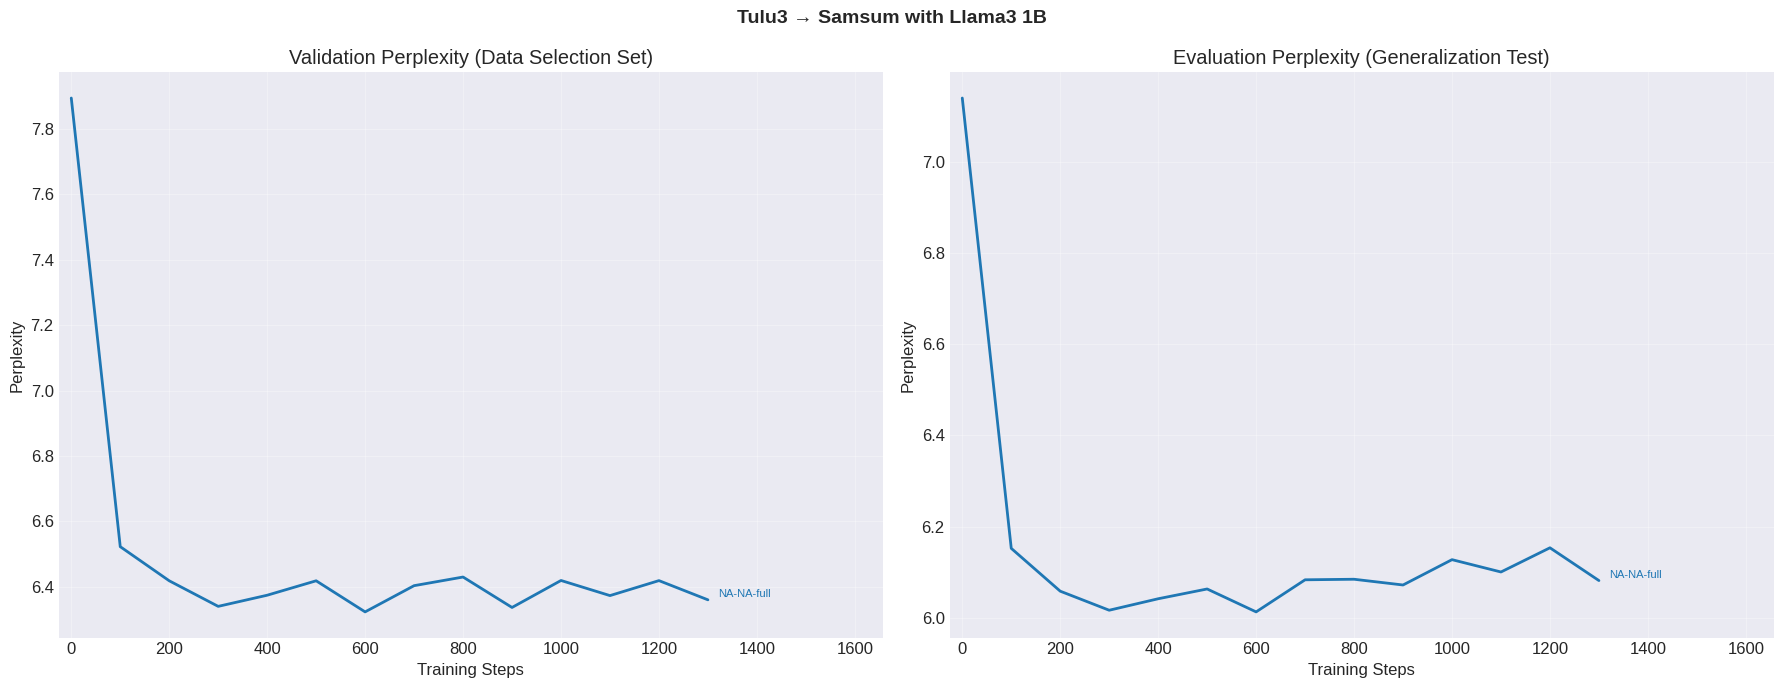

In [5]:
# Plotting configuration
max_steps = None  # Change to e.g., 100 to plot only first 100 steps
step_interval = None  # Change to e.g., 5 to plot every 5th step

# Build plot title based on train→task combination
train_name = train_dataset.replace('_', ' ').title()
task_name = task.upper() if task in ['tydiqa', 'mmlu', 'bbh', 'gsm8k'] else task.replace('_', ' ').title()
if subject:
    task_name = f"{task_name} ({subject.replace('_', ' ').title()})"
model_name = model.replace('_', ' ').replace('-', ' ').title()

plot_title = f"{train_name} → {task_name} with {model_name}"

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Add main title
fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=0.98)

# Plot validation perplexity (small set for data selection)
ax = axes[0]
texts_val = []
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        val_perp = data['val_perplexity'][mask]
    else:
        steps = data['steps']
        val_perp = data['val_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        val_perp = val_perp[indices]

    line, = ax.plot(steps, val_perp, linewidth=2)
    # Collect text annotations for automatic adjustment
    texts_val.append(ax.text(steps[-1], val_perp[-1], name, fontsize=8, color=line.get_color()))

ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity (Data Selection Set)')
ax.grid(True, alpha=0.3)
# Add right margin for annotations
ax.margins(x=0.02)
ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
# Adjust text positions to avoid overlaps
adjust_text(texts_val, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Plot evaluation perplexity (large held-out set)
ax = axes[1]
texts_eval = []
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        eval_perp = data['eval_perplexity'][mask]
    else:
        steps = data['steps']
        eval_perp = data['eval_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        eval_perp = eval_perp[indices]

    line, = ax.plot(steps, eval_perp, linewidth=2)
    # Collect text annotations for automatic adjustment
    texts_eval.append(ax.text(steps[-1], eval_perp[-1], name, fontsize=8, color=line.get_color()))

ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Evaluation Perplexity (Generalization Test)')
ax.grid(True, alpha=0.3)
# Add right margin for annotations
ax.margins(x=0.02)
ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
# Adjust text positions to avoid overlaps
adjust_text(texts_eval, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.tight_layout()
plt.show()

## Plot Perplexity vs. Wall Time (Compute-Time Trade-off)

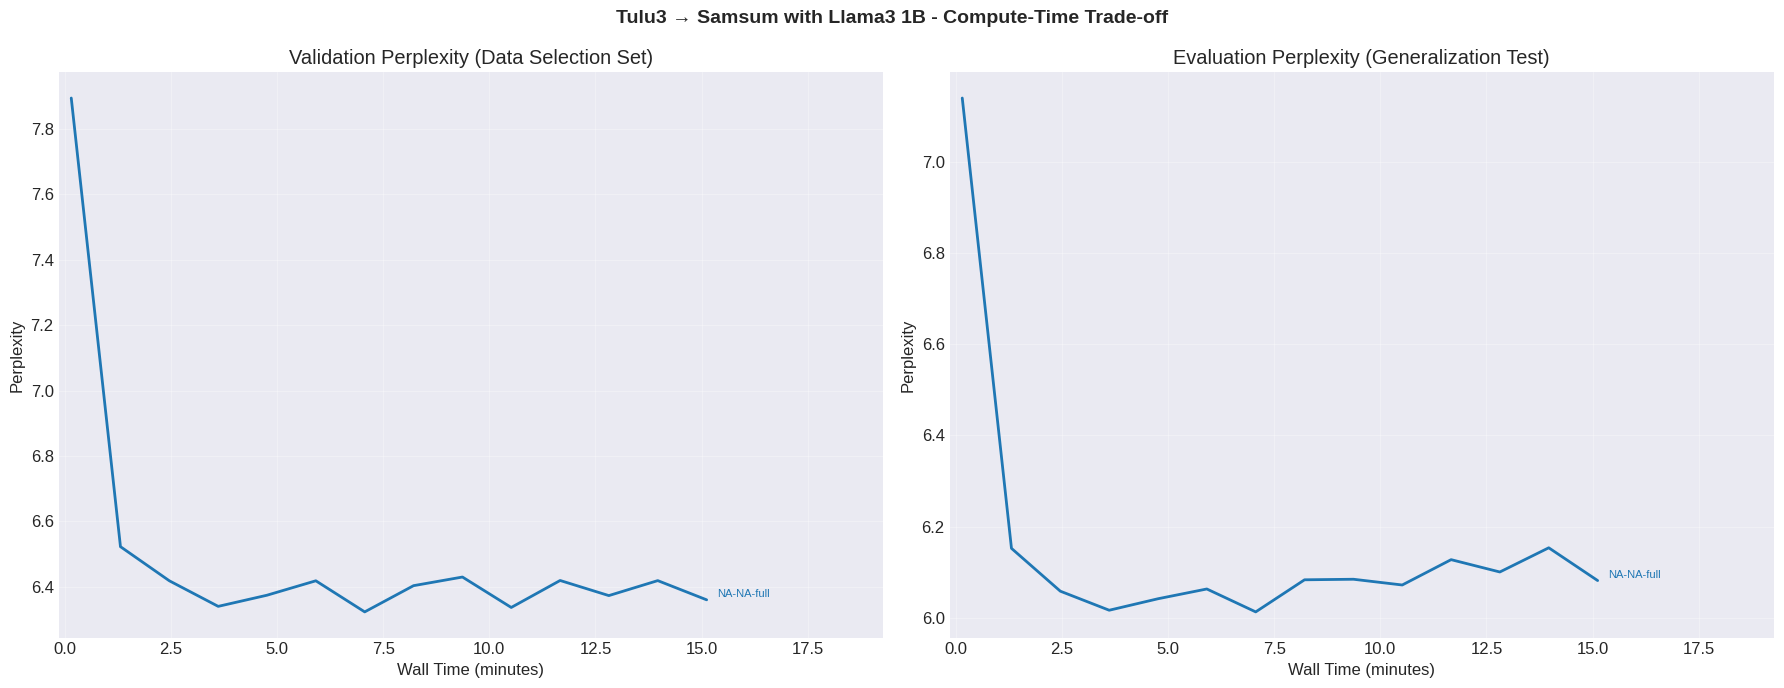

In [6]:
# Check if wall time data is available
has_wall_time = any(data['wall_time'] is not None for data in results.values())

if has_wall_time:
    # Plotting configuration
    max_wall_time = 2000  # Change to e.g., 3600 to plot only first hour (in seconds)

    # Build plot title
    plot_title_time = f"{train_name} → {task_name} with {model_name} - Compute-Time Trade-off"

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Add main title
    fig.suptitle(plot_title_time, fontsize=14, fontweight='bold', y=0.98)

    # Plot validation perplexity vs. wall time
    ax = axes[0]
    texts_val_time = []
    for name, data in results.items():
        if data['wall_time'] is not None:
            wall_time = data['wall_time']
            val_perp = data['val_perplexity']

            # Filter by max_wall_time if specified
            if max_wall_time is not None:
                mask = wall_time <= max_wall_time
                wall_time = wall_time[mask]
                val_perp = val_perp[mask]

            # Convert wall time to minutes for better readability
            wall_time_minutes = wall_time / 60.0
            line, = ax.plot(wall_time_minutes, val_perp, linewidth=2)
            # Collect text annotations for automatic adjustment
            texts_val_time.append(ax.text(wall_time_minutes[-1], val_perp[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel('Wall Time (minutes)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Validation Perplexity (Data Selection Set)')
    ax.grid(True, alpha=0.3)
    # Add right margin for annotations
    ax.margins(x=0.02)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
    # Adjust text positions to avoid overlaps
    adjust_text(texts_val_time, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # Plot evaluation perplexity vs. wall time
    ax = axes[1]
    texts_eval_time = []
    for name, data in results.items():
        if data['wall_time'] is not None:
            wall_time = data['wall_time']
            eval_perp = data['eval_perplexity']

            # Filter by max_wall_time if specified
            if max_wall_time is not None:
                mask = wall_time <= max_wall_time
                wall_time = wall_time[mask]
                eval_perp = eval_perp[mask]

            # Convert wall time to minutes for better readability
            wall_time_minutes = wall_time / 60.0
            line, = ax.plot(wall_time_minutes, eval_perp, linewidth=2)
            # Collect text annotations for automatic adjustment
            texts_eval_time.append(ax.text(wall_time_minutes[-1], eval_perp[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel('Wall Time (minutes)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Evaluation Perplexity (Generalization Test)')
    ax.grid(True, alpha=0.3)
    # Add right margin for annotations
    ax.margins(x=0.02)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
    # Adjust text positions to avoid overlaps
    adjust_text(texts_eval_time, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.tight_layout()
    plt.show()
else:
    print("Wall time data not available in the results.")
    print("Please re-run the training with the updated trainer to collect wall time data.")

## Compare Final Performance

In [7]:
# Print final results
print(f"\n{'='*80}")
print(f"Final Perplexity Results: {train_dataset} → {task}")
print(f"{'='*80}")
print(f"{'Method':<35} {'Val Perplexity':<18} {'Eval Perplexity':<18}")
print("-" * 80)

# Sort by eval perplexity for easier comparison
sorted_results = sorted(results.items(), key=lambda x: x[1]['eval_perplexity'][-1])

for name, data in sorted_results:
    final_val = data['val_perplexity'][-1]
    final_eval = data['eval_perplexity'][-1]
    print(f"{name:<35} {final_val:<18.4f} {final_eval:<18.4f}")

print("=" * 80)


Final Perplexity Results: tulu3 → samsum
Method                              Val Perplexity     Eval Perplexity   
--------------------------------------------------------------------------------
NA-NA-full                          6.3597             6.0817            


## Plot Improvement Over Baseline

In [8]:
def load_accuracy_results(result_path):
    """Load accuracy results from evaluation output files."""
    if not Path(result_path).exists():
        return None

    with open(result_path, 'r') as f:
        data = json.load(f)

    return data


def build_accuracy_path(train_dataset, task, method_name, result_type, config=None, subject=None):
    """Build the path for accuracy results using the same directory structure."""
    if method_name not in method_definitions:
        return None

    # Get method definition (4 elements)
    selection, compression, training_type, use_second_order = method_definitions[method_name]

    # Use default config or provided config
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']
    seed = cfg['seed']
    lr = cfg['lr_lora'] if training_type == 'lora' else cfg['lr_full']

    # Build method string: selection-compression[-2nd]
    method_str = f"{selection}-{compression}"

    # Add '-2nd' suffix for data selection with second-order interactions
    if selection != 'NA' and use_second_order:
        method_str = f"{method_str}-2nd"

    # Build setting string: model-job_type-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}
    setting_str = f"{model}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}"

    # Build task string (with subject for MMLU/BBH)
    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    # Full directory name
    dir_name = f"{train_dataset}_{task_str}-{method_str}-{setting_str}"

    return f"{out_dir}/{dir_name}/{result_type}_results.json"


# Determine result type based on task
if task == 'tydiqa':
    result_type = 'tydiqa'
elif task in ['mmlu', 'bbh']:
    result_type = 'mmlu'
elif task in ['gsm8k', 'math500']:
    result_type = 'math'
elif task == 'samsum':
    result_type = 'samsum'
else:
    result_type = task

# Build accuracy paths for FILTERED methods only
accuracy_experiments = {}
for method_name in filtered_methods.keys():
    path = build_accuracy_path(train_dataset, task, method_name, result_type, default_config, subject)
    if path:
        accuracy_experiments[method_name] = path

# Load all accuracy results
accuracy_results = {}
for name, path in accuracy_experiments.items():
    result = load_accuracy_results(path)
    if result is not None:
        accuracy_results[name] = result

# Print accuracy results
if accuracy_results:
    print(f"\n{'='*80}")
    print(f"Task-Specific Evaluation Results: {train_dataset} -> {task}")
    print(f"{'='*80}")

    if task == 'tydiqa':
        print(f"{'Method':<35} {'F1 Score':<15} {'Exact Match':<15} {'N_test':<10}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            f1 = data.get('f1_score', None)
            em = data.get('exact_match', None)
            n_test = data.get('n_test', 'N/A')

            f1_str = f"{f1:.2f}" if isinstance(f1, (int, float)) else str(f1) if f1 is not None else 'N/A'
            em_str = f"{em:.2f}" if isinstance(em, (int, float)) else str(em) if em is not None else 'N/A'

            print(f"{name:<35} {f1_str:<15} {em_str:<15} {n_test:<10}")

    elif task in ['mmlu', 'bbh']:
        print(f"{'Method':<35} {'Accuracy (%)':<15} {'Correct/Total':<20}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            accuracy = data.get('accuracy', None)
            correct = data.get('num_correct', None)
            total = data.get('num_total', None)

            acc_str = f"{accuracy*100:.2f}" if isinstance(accuracy, (int, float)) else str(accuracy) if accuracy is not None else 'N/A'
            ct_str = f"{correct}/{total}" if correct is not None and total is not None else 'N/A'

            print(f"{name:<35} {acc_str:<15} {ct_str:<20}")

    elif task in ['gsm8k', 'math500']:
        print(f"{'Method':<35} {'Accuracy (%)':<15} {'Correct/Total':<20}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            accuracy = data.get('accuracy', None)
            correct = data.get('num_correct', None)
            total = data.get('num_total', None)

            acc_str = f"{accuracy*100:.2f}" if isinstance(accuracy, (int, float)) else str(accuracy) if accuracy is not None else 'N/A'
            ct_str = f"{correct}/{total}" if correct is not None and total is not None else 'N/A'

            print(f"{name:<35} {acc_str:<15} {ct_str:<20}")

    elif task == 'samsum':
        print(f"{'Method':<35} {'ROUGE-1':<12} {'ROUGE-2':<12} {'ROUGE-L':<12}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            rouge1 = data.get('rouge1', None)
            rouge2 = data.get('rouge2', None)
            rougeL = data.get('rougeL', None)

            r1_str = f"{rouge1:.2f}" if isinstance(rouge1, (int, float)) else 'N/A'
            r2_str = f"{rouge2:.2f}" if isinstance(rouge2, (int, float)) else 'N/A'
            rL_str = f"{rougeL:.2f}" if isinstance(rougeL, (int, float)) else 'N/A'

            print(f"{name:<35} {r1_str:<12} {r2_str:<12} {rL_str:<12}")
    else:
        # Generic output for unknown task types
        print("Results:")
        for name, data in accuracy_results.items():
            print(f"\n{name}:")
            for key, value in data.items():
                print(f"  {key}: {value}")

    print("=" * 80)
else:
    print(f"\nNo accuracy results found for {train_dataset} -> {task}.")
    print("This is expected if evaluations haven't been run yet.")


No accuracy results found for tulu3 -> samsum.
This is expected if evaluations haven't been run yet.
